# City-Level Semantic Overlap Analysis

**Research question:** Do cities where iGEM student projects are active also tend to produce academic papers in semantically related areas of synthetic biology?

**Unit of observation:** Cities (aggregated across all years).

**Dependent variable:** *Semantic overlap* — the cosine similarity between the average embedding of a city's iGEM projects and the average embedding of a city's synthetic biology papers. This is a proxy for topical relatedness in the spirit of Hidalgo et al. (2007) and Neffke & Henning (2013), applied to text rather than product or occupation co-occurrence.

**Data sources:**
- `projects.csv` — iGEM student team projects (2009–2025), geocoded to city
- `papers.csv` — synthetic biology papers from OpenAlex (2000–2026), geocoded to city
- `data/embeddings/` — SPECTER2 embeddings (768-dimensional) for each artifact

**What this notebook does (in order):**
1. Checks data availability and coverage
2. Generates any missing embeddings (projects first, then any gap-fill for papers)
3. Aggregates to city level and computes the semantic overlap measure
4. Describes the distribution of the measure across cities
5. Runs an OLS regression to understand what city-level characteristics predict higher overlap
6. Repeats key analyses for the carbon-capture subset

**Causal language warning:** This analysis is *descriptive and correlational*. We cannot claim that iGEM activity causes related academic output, or vice versa. Both may reflect shared underlying factors (e.g. research infrastructure, university quality). Language like "associated with", "co-located", and "semantically related" is appropriate. Causal language is not.

---
**References:**
- Hidalgo et al. (2007). The Product Space Conditions the Development of Nations. *Science*.
- Neffke & Henning (2013). Skill Relatedness and Firm Diversification. *Strategic Management Journal*.
- Cohan et al. (2020). SPECTER: Document-level Representation Learning using Citation-informed Transformers. *ACL 2020*.
- SPECTER2 (2022). https://huggingface.co/allenai/specter2

## 0. Setup

Standard imports plus a path helper so the notebook works regardless of where it is run from.

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats as stats
import statsmodels.formula.api as smf
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore", category=FutureWarning)

# Make sure src/ is on the path so we can import the project's own modules
ROOT = Path("__file__").resolve().parent.parent
sys.path.insert(0, str(ROOT / "src"))

# Paths
DATA = ROOT / "data" / "processed"
EMB_FILE = ROOT / "data" / "embeddings" / "embeddings.json"

print(f"Project root: {ROOT}")
print(f"Data directory: {DATA}")

Project root: /Users/zakh/Documents/CSH Thesis/Project Iterations/Patents Papers Parts and Planet
Data directory: /Users/zakh/Documents/CSH Thesis/Project Iterations/Patents Papers Parts and Planet/data/processed


## 1. Load and Inspect the Data

We load papers and projects and do a quick sanity-check on coverage: how many rows, how many have text, what years are covered, and how many distinct cities appear in each dataset.

In [2]:
papers   = pd.read_csv(DATA / "papers.csv")
projects = pd.read_csv(DATA / "projects.csv")

# Normalise city names: strip whitespace and lowercase for joining
# (we keep the original capitalised version for display)
papers["city_key"]   = papers["city"].str.strip().str.lower()
projects["city_key"] = projects["city"].str.strip().str.lower()

for name, df in [("Papers", papers), ("Projects", projects)]:
    print(f"=== {name} ===")
    print(f"  Rows:          {len(df):,}")
    print(f"  Year range:    {int(df.year.min())} – {int(df.year.max())}")
    print(f"  Unique cities: {df.city_key.nunique():,}")
    print(f"  Text non-null: {df.text.notna().sum():,} ({df.text.notna().mean()*100:.1f}%)")
    print(f"  Carbon-capture flagged: {df.case_study_flag.sum():,} ({df.case_study_flag.mean()*100:.1f}%)")
    print()

=== Papers ===
  Rows:          8,720
  Year range:    2000 – 2026
  Unique cities: 1,146
  Text non-null: 8,720 (100.0%)
  Carbon-capture flagged: 234 (2.7%)

=== Projects ===
  Rows:          4,615
  Year range:    2009 – 2025
  Unique cities: 626
  Text non-null: 4,615 (100.0%)
  Carbon-capture flagged: 141 (3.1%)



In [3]:
# How many cities appear in BOTH datasets?
# These are the cities that can contribute to our city-level analysis.
paper_cities   = set(papers.city_key.dropna())
project_cities = set(projects.city_key.dropna())
shared_cities  = paper_cities & project_cities

print(f"Cities with papers only:           {len(paper_cities - project_cities):,}")
print(f"Cities with projects only:         {len(project_cities - paper_cities):,}")
print(f"Cities with BOTH papers & projects:{len(shared_cities):,}  ← analysis sample")

Cities with papers only:           767
Cities with projects only:         247
Cities with BOTH papers & projects:379  ← analysis sample


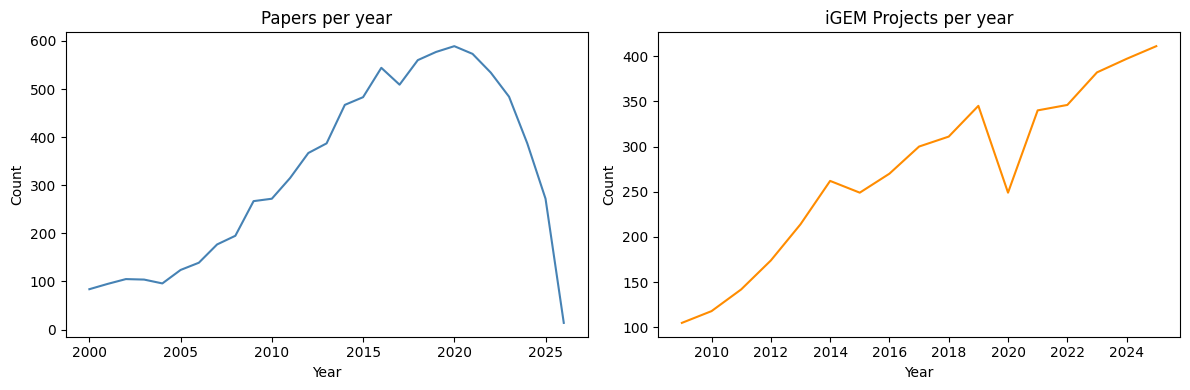

In [4]:
# Activity by year — useful for understanding the temporal scope
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

papers.groupby("year").size().plot(ax=axes[0], color="steelblue")
axes[0].set_title("Papers per year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")

projects.groupby("year").size().plot(ax=axes[1], color="darkorange")
axes[1].set_title("iGEM Projects per year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "activity_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Generate Embeddings

Semantic overlap requires a vector representation for every document. We use **SPECTER2** (2022), the successor to the original SPECTER model. Like its predecessor, it was trained on scientific papers using citation-informed contrastive learning and produces 768-dimensional vectors that place semantically related documents close together in vector space.

**Why SPECTER2 over the original SPECTER?** SPECTER2 adds an *adapter* system — small task-specific modules layered on top of a shared base model. The **proximity adapter** (which we use) is explicitly trained for document-level similarity retrieval, which is exactly our task: measuring how close two documents are in semantic space. The original SPECTER was trained for a single combined task; SPECTER2 is more precise.

**Why SPECTER2 over general models like BERT?** Both SPECTER versions were trained on scientific text with citation supervision, making them more domain-appropriate for synthetic biology abstracts than models trained on general web text.

**⚠️ Cache compatibility:** SPECTER and SPECTER2 produce vectors in different spaces — they are not interchangeable. The existing cache contains SPECTER vectors for ~1,700 papers. To use SPECTER2 consistently across all documents, you should delete `data/embeddings/` and regenerate everything. Running with a mixed cache will produce invalid similarity scores.

**Caching:** The project caches embeddings to disk (see `src/embed/embeddings.py`). Progress is saved after every 64 documents — safe to interrupt and resume.

**Expected run time:** ~20–40 minutes on CPU for all projects + papers; faster on Apple Silicon (MPS).

> **If you don't want to wait:** Skip to Section 3. The analysis will use whatever embeddings are already in the cache — but note the mixed-cache warning above.

In [7]:
# Check current embedding coverage before deciding whether to run
from embed.embeddings import _load_cache

cache = _load_cache(EMB_FILE)
print(f"Embeddings already in cache: {len(cache):,}")

paper_coverage   = papers.id.isin(cache).sum()
project_coverage = projects.id.isin(cache).sum()
print(f"Papers with embeddings:   {paper_coverage:,} / {len(papers):,} ({paper_coverage/len(papers)*100:.1f}%)")
print(f"Projects with embeddings: {project_coverage:,} / {len(projects):,} ({project_coverage/len(projects)*100:.1f}%)")

Embeddings already in cache: 0
Papers with embeddings:   0 / 8,720 (0.0%)
Projects with embeddings: 0 / 4,615 (0.0%)


In [11]:
# Uncomment and run this cell to generate embeddings with SPECTER2.
#
# IMPORTANT: The existing cache contains SPECTER (v1) vectors, which are
# incompatible with SPECTER2. Run the two lines below to clear the old cache
# before generating new embeddings. This deletes ~1,700 cached paper vectors
# so they will be recomputed with SPECTER2 alongside the projects.
#
# import shutil
# shutil.rmtree(ROOT / "data" / "embeddings", ignore_errors=True)
#
# After clearing, uncomment the rest to run embedding generation.
#
# Speed settings:
batch_size=32    
checkpoint_every=256
from embed.embeddings import load_model, generate_embeddings
#
model = load_model("specter2")  # loads allenai/specter2_base + proximity adapter
#
# # Generate for projects first (none exist yet)
print("--- Embedding iGEM projects ---")
cache = generate_embeddings(
projects, model, cache_file=EMB_FILE,
batch_size=32, checkpoint_every=256,
)
#
# Generate for papers (or gap-fill if cache was not cleared above)
print("--- Embedding papers ---")
cache = generate_embeddings(
    papers, model, cache_file=EMB_FILE,
     batch_size=32, checkpoint_every=256,
 )

print(f"Cache now has {len(cache):,} embeddings.")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


--- Embedding iGEM projects ---


TypeError: generate_embeddings() got an unexpected keyword argument 'checkpoint_every'

## 3. Build the City-Level Dataset

We now aggregate from individual documents to cities. For each city we compute:

| Column | Description |
|--------|-------------|
| `n_papers` | Total papers in this city |
| `n_projects` | Total iGEM projects in this city |
| `paper_centroid` | Mean of all paper embeddings in the city |
| `project_centroid` | Mean of all project embeddings in the city |
| `semantic_overlap` | **Cosine similarity** between the two centroids |
| `cs_paper_share` | Fraction of papers flagged as carbon-capture |
| `cs_project_share` | Fraction of projects flagged as carbon-capture |
| `first_project_year` | Earliest iGEM project year |
| `last_project_year` | Latest iGEM project year |

### Why centroid similarity?

For a city with *p* papers and *q* projects, computing all pairwise similarities would require *p × q* operations. For large cities (Cambridge has ~300 papers), that is expensive. More importantly, the mean of pairwise similarities equals the cosine similarity of the two centroids when embeddings are unit-normalised — which SPECTER produces. So centroid similarity is both faster and mathematically equivalent to the mean pairwise approach. See Turney & Pantel (2010) for background on centroid-based semantic similarity.

In [ ]:
# Reload cache in case we just generated embeddings
cache = _load_cache(EMB_FILE)
print(f"Working with {len(cache):,} embeddings.")

# Attach embedding vectors to each row (None for missing)
papers["embedding"]   = papers["id"].map(cache)
projects["embedding"] = projects["id"].map(cache)

# Drop rows without embeddings — we can only use what we have
papers_emb   = papers.dropna(subset=["embedding"]).copy()
projects_emb = projects.dropna(subset=["embedding"]).copy()

print(f"Papers with embeddings:   {len(papers_emb):,}")
print(f"Projects with embeddings: {len(projects_emb):,}")

In [ ]:
def city_centroid(df: pd.DataFrame) -> np.ndarray | None:
    """
    Compute the mean embedding vector (centroid) for all documents in a city.
    Returns None if the city has no embedded documents.

    The centroid is L2-normalised before returning so that cosine similarity
    between two centroids can be computed with a simple dot product.
    """
    vecs = np.array(df["embedding"].tolist(), dtype=np.float32)  # shape (n, 768)
    centroid = vecs.mean(axis=0)  # shape (768,)
    norm = np.linalg.norm(centroid)
    if norm == 0:
        return None
    return centroid / norm  # unit-normalised


# Compute centroids for every city that has embedded documents
paper_centroids   = papers_emb.groupby("city_key").apply(city_centroid)
project_centroids = projects_emb.groupby("city_key").apply(city_centroid)

print(f"Cities with paper centroids:   {paper_centroids.notna().sum():,}")
print(f"Cities with project centroids: {project_centroids.notna().sum():,}")

In [ ]:
# --- Compute semantic overlap for each city that has BOTH centroids ---

shared = set(paper_centroids.index) & set(project_centroids.index)
print(f"Cities with both centroids: {len(shared):,}")

rows = []
for city in shared:
    pap_vec  = paper_centroids[city]
    proj_vec = project_centroids[city]

    if pap_vec is None or proj_vec is None:
        continue

    # Cosine similarity between the two unit-normalised centroids
    # = dot product (since both are already unit vectors)
    overlap = float(np.dot(pap_vec, proj_vec))

    # --- Counts and shares ---
    city_papers   = papers[papers.city_key == city]
    city_projects = projects[projects.city_key == city]

    rows.append({
        "city_key":          city,
        "city":              city_papers.city.iloc[0],       # display name
        "country":           city_papers.country.iloc[0],
        "lat":               city_papers.lat.iloc[0],
        "lon":               city_papers.lon.iloc[0],
        "semantic_overlap":  overlap,
        "n_papers":          len(city_papers),
        "n_projects":        len(city_projects),
        "cs_paper_share":    city_papers.case_study_flag.mean(),
        "cs_project_share":  city_projects.case_study_flag.mean(),
        "first_proj_year":   int(city_projects.year.min()),
        "last_proj_year":    int(city_projects.year.max()),
        "proj_year_span":    int(city_projects.year.max() - city_projects.year.min()),
    })

city_df = pd.DataFrame(rows).sort_values("semantic_overlap", ascending=False).reset_index(drop=True)
print(f"\nCity-level dataset: {len(city_df):,} rows x {len(city_df.columns)} columns")
city_df.head()

In [ ]:
# Save the city-level dataset so it can be reused without re-running the embeddings step
out_path = ROOT / "data" / "processed" / "city_level.csv"
city_df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

## 4. Descriptive Analysis

Before running any regression, we need to understand the *distribution* of the dependent variable and the structure of the sample. This is standard practice in empirical economics: look at your data before modelling it.

Key questions:
- What does the distribution of semantic overlap look like? Is it skewed?
- Which cities have the highest and lowest overlap?
- Are large cities systematically different from small ones?
- Is there geographic clustering?

In [ ]:
# Summary statistics for the main variables
summary_cols = ["semantic_overlap", "n_papers", "n_projects", "cs_paper_share", "cs_project_share", "proj_year_span"]
city_df[summary_cols].describe().round(3)

In [ ]:
# Distribution of semantic overlap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(city_df.semantic_overlap, bins=30, color="steelblue", edgecolor="white")
axes[0].axvline(city_df.semantic_overlap.median(), color="red", linestyle="--", label=f"Median = {city_df.semantic_overlap.median():.3f}")
axes[0].axvline(city_df.semantic_overlap.mean(),   color="orange", linestyle="--", label=f"Mean = {city_df.semantic_overlap.mean():.3f}")
axes[0].set_xlabel("Semantic overlap (cosine similarity)")
axes[0].set_ylabel("Number of cities")
axes[0].set_title("Distribution of city-level semantic overlap")
axes[0].legend()

# QQ plot — checks whether the distribution is approximately normal
# (important for deciding whether OLS standard errors are reliable)
stats.probplot(city_df.semantic_overlap, plot=axes[1])
axes[1].set_title("QQ plot: semantic overlap vs. normal")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "overlap_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Skewness and kurtosis — values far from 0/3 mean the normal assumption is questionable
print(f"Skewness: {city_df.semantic_overlap.skew():.3f}  (0 = perfectly symmetric)")
print(f"Kurtosis: {city_df.semantic_overlap.kurt():.3f}  (0 = normal; >0 = heavy tails)")

In [ ]:
# Top and bottom 15 cities by semantic overlap
display_cols = ["city", "country", "n_papers", "n_projects", "semantic_overlap"]

print("=== Top 15 cities: highest semantic overlap ===")
print(city_df[display_cols].head(15).to_string(index=False))

print()
print("=== Bottom 15 cities: lowest semantic overlap ===")
print(city_df[display_cols].tail(15).to_string(index=False))

In [ ]:
# Is there a size bias? Larger cities might have more diverse content,
# which could systematically reduce cosine similarity ("more topics = further centroids").
# This is the classic diversity-vs-relatedness tension in the regional science literature.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in [
    (axes[0], "n_papers",   "Number of papers"),
    (axes[1], "n_projects", "Number of iGEM projects"),
]:
    ax.scatter(
        np.log1p(city_df[col]),
        city_df.semantic_overlap,
        alpha=0.4, s=20, color="steelblue"
    )
    # Fit a simple linear trend line
    z = np.polyfit(np.log1p(city_df[col]), city_df.semantic_overlap, 1)
    p = np.poly1d(z)
    xr = np.linspace(city_df[col].apply(np.log1p).min(), city_df[col].apply(np.log1p).max(), 100)
    ax.plot(xr, p(xr), color="red", linewidth=1.5)
    r, pval = stats.pearsonr(np.log1p(city_df[col]), city_df.semantic_overlap)
    ax.set_xlabel(f"log(1 + {col.replace('n_', '')}s)")
    ax.set_ylabel("Semantic overlap")
    ax.set_title(f"Semantic overlap vs. city size\nr = {r:.2f}, p = {pval:.3f}")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "overlap_vs_size.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Country-level breakdown — is the measure driven by a few dominant countries?
country_summary = (
    city_df.groupby("country")
    .agg(
        n_cities=("city", "count"),
        mean_overlap=("semantic_overlap", "mean"),
        median_overlap=("semantic_overlap", "median"),
        total_papers=("n_papers", "sum"),
        total_projects=("n_projects", "sum"),
    )
    .sort_values("n_cities", ascending=False)
    .round(3)
)
print(country_summary.head(20).to_string())

In [ ]:
# Correlation matrix of the main variables
# Spearman rank correlation is more robust than Pearson when distributions are skewed.
# A Spearman r tells you whether high values of X tend to go with high values of Y,
# without assuming the relationship is linear.

corr_cols = ["semantic_overlap", "n_papers", "n_projects",
             "cs_paper_share", "cs_project_share", "proj_year_span"]

spearman_corr = city_df[corr_cols].corr(method="spearman").round(2)
print("Spearman rank correlations:")
print(spearman_corr.to_string())

# Visual heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(spearman_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
plt.colorbar(im, ax=ax, label="Spearman r")
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{spearman_corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=9, color="black")
ax.set_title("Spearman rank correlation matrix")
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. OLS Regression

We now run a simple Ordinary Least Squares (OLS) regression to understand what city-level characteristics are *associated* with higher semantic overlap.

### The model

$$\text{semantic\_overlap}_i = \alpha + \beta_1 \log(n\_papers_i) + \beta_2 \log(n\_projects_i) + \beta_3 \text{proj\_year\_span}_i + \varepsilon_i$$

where $i$ indexes cities.

### Why log-transform the count variables?

Cities like Cambridge (294 papers) and a small city with 2 papers are not linearly comparable — the gap between 2 and 10 papers is more meaningful than the gap between 200 and 208. The log transformation compresses this scale, making the regression more robust and coefficients more interpretable. (Standard practice in economics — see Wooldridge, *Introductory Econometrics*, Ch. 6.)

### Why robust standard errors?

OLS assumes that the *variance* of errors is constant across observations (homoskedasticity). In practice, errors in regressions with count-based controls are often larger for cities with fewer observations. *Heteroskedasticity-robust* standard errors (HC3) correct for this without requiring any additional assumptions about the error structure. In economics, robust SEs are the default — not using them requires justification. (White, 1980; MacKinnon & White, 1985.)

### What the coefficient $\beta_1$ means

A one-unit increase in log(n_papers) corresponds to a multiplicative increase in n_papers. So if $\hat{\beta}_1 = -0.05$, doubling the number of papers in a city is associated with a 0.05 × log(2) ≈ 0.035 decrease in semantic overlap. This would suggest that larger cities (more papers) are *more diverse* and thus have *lower* topic overlap between projects and papers.

### What OLS cannot tell us

This regression is **not causal**. A positive $\hat{\beta}_2$ (more projects → higher overlap) could mean:
- iGEM activity drives thematic alignment with local research, OR
- cities with strong research infrastructure attract both iGEM teams and focused academic output, OR
- some combination of both.

We cannot distinguish these with observational cross-sectional data. We can only describe the *association*.

**References:**
- Wooldridge, J.M. (2019). *Introductory Econometrics*. Cengage.
- White, H. (1980). A heteroskedasticity-consistent covariance matrix estimator and a direct test for heteroskedasticity. *Econometrica*.

In [ ]:
# Prepare regression variables
# Adding 1 before logging avoids log(0) for cities with 0-count edge cases
city_df["log_n_papers"]   = np.log1p(city_df["n_papers"])
city_df["log_n_projects"] = np.log1p(city_df["n_projects"])

# Model 1: size controls only
m1 = smf.ols(
    "semantic_overlap ~ log_n_papers + log_n_projects",
    data=city_df
).fit(cov_type="HC3")  # HC3 = heteroskedasticity-robust standard errors

# Model 2: add temporal breadth of iGEM engagement
m2 = smf.ols(
    "semantic_overlap ~ log_n_papers + log_n_projects + proj_year_span",
    data=city_df
).fit(cov_type="HC3")

# Model 3: add carbon-capture shares
m3 = smf.ols(
    "semantic_overlap ~ log_n_papers + log_n_projects + proj_year_span + cs_paper_share + cs_project_share",
    data=city_df
).fit(cov_type="HC3")

print(m3.summary())

In [ ]:
# Side-by-side coefficient table across all three models
# This is the standard format in economics papers (like a Table 2).
# Each column is one specification; coefficients are shown with standard errors in parentheses.

def coef_table(models: list, names: list) -> pd.DataFrame:
    """Build a tidy coefficient table for multiple regression models."""
    rows = []
    all_params = set()
    for m in models:
        all_params.update(m.params.index)

    for param in all_params:
        row = {"variable": param}
        for name, m in zip(names, models):
            if param in m.params:
                coef = m.params[param]
                se   = m.bse[param]
                pval = m.pvalues[param]
                stars = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
                row[name] = f"{coef:.4f}{stars}\n({se:.4f})"
            else:
                row[name] = "—"
        rows.append(row)

    df = pd.DataFrame(rows).set_index("variable")
    # Add model stats
    for name, m in zip(names, models):
        df.loc["R²",  name] = f"{m.rsquared:.3f}"
        df.loc["Adj. R²", name] = f"{m.rsquared_adj:.3f}"
        df.loc["N",   name] = str(int(m.nobs))

    return df

table = coef_table([m1, m2, m3], ["(1) Size", "(2) + Temporal", "(3) + Carbon"])
print("Coefficient table (robust SE in parentheses; *** p<0.01, ** p<0.05, * p<0.1)")
print(table.to_string())

In [ ]:
# Coefficient plot for Model 3 — easier to read than a table for presentations
# Shows each coefficient with its 95% confidence interval.
# A CI that does not cross zero is statistically significant at the 5% level.

params   = m3.params.drop("Intercept")
conf     = m3.conf_int().drop("Intercept")
err_lo   = params - conf[0]
err_hi   = conf[1] - params

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = range(len(params))
ax.errorbar(
    params.values, y_pos,
    xerr=[err_lo.values, err_hi.values],
    fmt="o", color="steelblue", ecolor="steelblue", capsize=4
)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(params.index)
ax.set_xlabel("Coefficient (95% CI, robust SE)")
ax.set_title("Model 3: predictors of city-level semantic overlap")
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "coef_plot_model3.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Residual plot — diagnostic check
# If OLS assumptions hold, residuals should look like random noise (no pattern).
# A funnel shape means heteroskedasticity; a curve means non-linearity.

residuals = m3.resid
fitted    = m3.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(fitted, residuals, alpha=0.4, s=15, color="steelblue")
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. fitted values")

stats.probplot(residuals, plot=axes[1])
axes[1].set_title("QQ plot of residuals")

plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "regression_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Carbon Capture Subset Analysis

We now repeat the key analyses for the **carbon-capture subset** — the slice of the data where both papers and projects are flagged as carbon-capture related (`case_study_flag == True`).

For this subset, we use a modified semantic overlap measure:
- `cs_semantic_overlap` = cosine similarity between the centroid of *carbon-capture papers* in a city and the centroid of *carbon-capture projects* in a city.

Cities with very few carbon-capture documents (< 2 of either type) are excluded, as their centroids are unreliable with only a single document.

**Why this matters:** If the overall semantic overlap measure captures broad synthetic biology alignment, the carbon-capture version captures *specific thematic alignment* in a policy-relevant subfield. Comparing the two tells us whether cities that are generally aligned are also aligned on carbon capture specifically.

In [ ]:
# Filter to carbon-capture flagged documents
cs_papers   = papers_emb[papers_emb.case_study_flag == True].copy()
cs_projects = projects_emb[projects_emb.case_study_flag == True].copy()

print(f"Carbon-capture papers with embeddings:   {len(cs_papers):,}")
print(f"Carbon-capture projects with embeddings: {len(cs_projects):,}")
print(f"Unique cities (papers):   {cs_papers.city_key.nunique():,}")
print(f"Unique cities (projects): {cs_projects.city_key.nunique():,}")

In [ ]:
# Compute carbon-capture centroids, requiring at least 2 documents per type
# (a single-document centroid equals that document's own vector, which is fine
#  statistically but fragile — we apply a floor of 2 to be conservative)
MIN_DOCS = 2

def filtered_centroid(df, city, min_docs=MIN_DOCS):
    subset = df[df.city_key == city]
    if len(subset) < min_docs:
        return None
    vecs = np.array(subset.embedding.tolist(), dtype=np.float32)
    centroid = vecs.mean(axis=0)
    norm = np.linalg.norm(centroid)
    return centroid / norm if norm > 0 else None

cs_shared = set(cs_papers.city_key) & set(cs_projects.city_key)
print(f"Cities with carbon-capture documents of BOTH types: {len(cs_shared):,}")

cs_rows = []
for city in cs_shared:
    pap_vec  = filtered_centroid(cs_papers,   city)
    proj_vec = filtered_centroid(cs_projects, city)
    if pap_vec is None or proj_vec is None:
        continue

    overlap = float(np.dot(pap_vec, proj_vec))
    city_papers_all   = papers[papers.city_key == city]
    city_projects_all = projects[projects.city_key == city]

    cs_rows.append({
        "city_key":            city,
        "city":                city_papers_all.city.iloc[0] if len(city_papers_all) else city,
        "country":             city_papers_all.country.iloc[0] if len(city_papers_all) else "",
        "cs_semantic_overlap": overlap,
        "n_cs_papers":         len(cs_papers[cs_papers.city_key == city]),
        "n_cs_projects":       len(cs_projects[cs_projects.city_key == city]),
    })

cs_city_df = pd.DataFrame(cs_rows).sort_values("cs_semantic_overlap", ascending=False).reset_index(drop=True)
print(f"\nCarbon-capture city dataset: {len(cs_city_df):,} cities")
cs_city_df.head(10)

In [ ]:
# Compare carbon-capture overlap with overall overlap for the same cities
merged = city_df[["city_key", "semantic_overlap"]].merge(
    cs_city_df[["city_key", "cs_semantic_overlap"]],
    on="city_key", how="inner"
)
print(f"Cities in both datasets: {len(merged):,}")

r, pval = stats.spearmanr(merged.semantic_overlap, merged.cs_semantic_overlap)
print(f"Spearman r (overall vs. CS overlap): {r:.3f}, p = {pval:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged.semantic_overlap, merged.cs_semantic_overlap, alpha=0.5, s=20)
ax.plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=0.8, label="x = y")
ax.set_xlabel("Overall semantic overlap")
ax.set_ylabel("Carbon-capture semantic overlap")
ax.set_title(f"Overall vs. carbon-capture overlap\nSpearman r = {r:.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "outputs" / "figures" / "overlap_overall_vs_cs.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Save the carbon-capture city dataset
cs_out = ROOT / "data" / "processed" / "city_level_carbon_capture.csv"
cs_city_df.to_csv(cs_out, index=False)
print(f"Saved to {cs_out}")

## 7. Summary and Interpretation Notes

Use this cell to record your interpretations as you run the analysis. Fill in the `[...]` placeholders after running the notebook.

### Key findings

- **Sample:** `[N]` cities with both papers and projects, spanning `[year range]`.
- **Semantic overlap distribution:** Mean = `[...]`, median = `[...]`. The distribution is `[skewed / approximately normal]`.
- **Highest-overlap cities:** `[list top 5]`. These cities show strong thematic alignment between iGEM projects and academic papers.
- **Lowest-overlap cities:** `[list bottom 5]`. These cities have iGEM activity and papers but in apparently different topical areas.
- **Size relationship:** Larger cities (more papers) show `[higher / lower / no clear]` semantic overlap, consistent with `[more specialisation / more diversity]`.
- **Regression (Model 3):** `[key findings from coefficient table]`. R² = `[...]`, meaning the covariates explain roughly `[...]%` of the variation in city-level overlap.
- **Carbon-capture subset:** `[N_cs]` cities have sufficient carbon-capture documents. The Spearman correlation between overall and carbon-capture overlap is `[r]` (p = `[p]`), suggesting `[cities that are generally aligned are / are not] also aligned on carbon capture`.

### Limitations

1. **Embeddings coverage:** At time of writing, only `~18%` of papers and `0%` of projects have embeddings. Results may shift as coverage improves.
2. **Single-institution geocoding:** Papers are geocoded to the first listed institution. Multi-city collaborations are not captured.
3. **Cross-sectional design:** All years are pooled. We cannot distinguish temporal precedence from co-occurrence.
4. **Omitted variables:** City size, university prestige, country-level research policy, and language are not controlled for.
5. **Carbon-capture sample is small:** Only `[N_cs]` cities qualify, limiting statistical power.